In [1]:
"""
Predicting Used Car Market Values Using ML Regression Models
ITCS 3156 Final Project

Name: Bryan Witherspoon

Dataset: Craigslist Used Cars/Trucks (Kaggle)
Source: https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data
"""

'\nPredicting Used Car Market Values Using ML Regression Models\nITCS 3156 Final Project\n\nName: Bryan Witherspoon\n\nDataset: Craigslist Used Cars/Trucks (Kaggle)\nSource: https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data\n'

In [2]:
from typing import List, Dict, Tuple, Callable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error as mse
import warnings
warnings.filterwarnings('ignore')
np.set_printoptions(suppress=True)

==============================
1. Load and Explore Data
==============================

In [3]:
df_raw = pd.read_csv('vehicles.csv')
print(f"Raw dataset shape: {df_raw.shape}")

Raw dataset shape: (426880, 26)


In [4]:
cols_to_keep = ['price', 'year', 'manufacturer', 'condition', 'cylinders',
                'fuel', 'odometer', 'transmission', 'drive', 'type', 'paint_color']
df = df_raw[cols_to_keep].copy()
df = df.dropna()
df['cylinders'] = df['cylinders'].str.extract(r'(\d+)').astype(float)
df = df.dropna(subset=['cylinders'])
df['cylinders'] = df['cylinders'].astype(int)
df = df[(df['price'] > 1000) & (df['price'] < 100000)]
df = df[(df['odometer'] > 100) & (df['odometer'] < 300000)]
df = df[(df['year'] >= 2000) & (df['year'] <= 2024)]
if len(df) > 15000:
    df = df.sample(n=15000, random_state=42)
df = df.reset_index(drop=True)
print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (15000, 11)


==============================
2. EDA
==============================

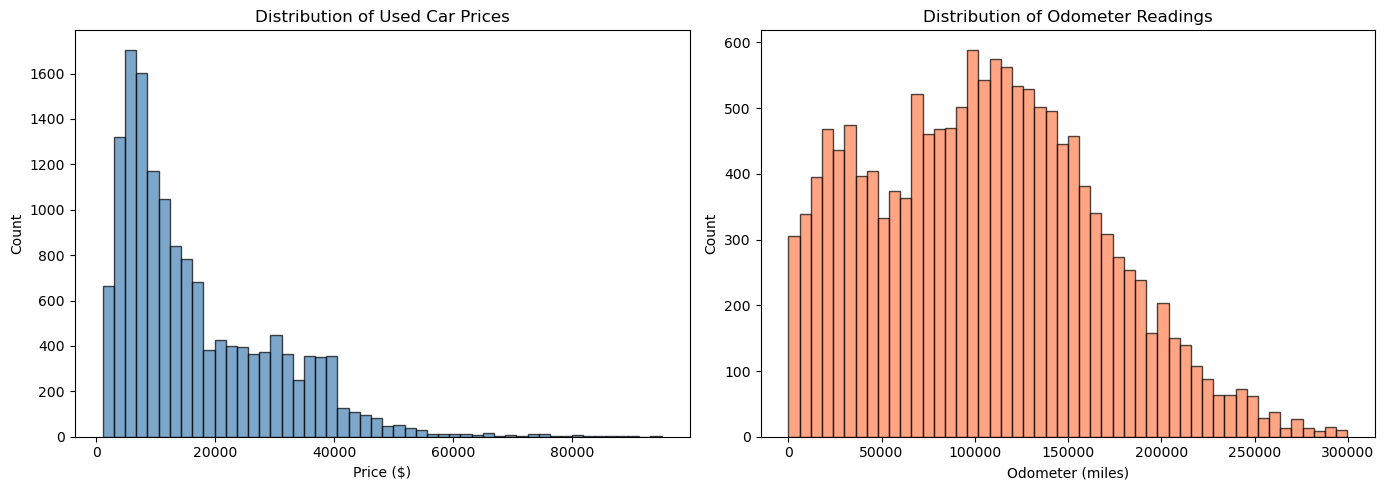

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Used Car Prices'); axes[0].set_xlabel('Price ($)'); axes[0].set_ylabel('Count')
axes[1].hist(df['odometer'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Odometer Readings'); axes[1].set_xlabel('Odometer (miles)'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

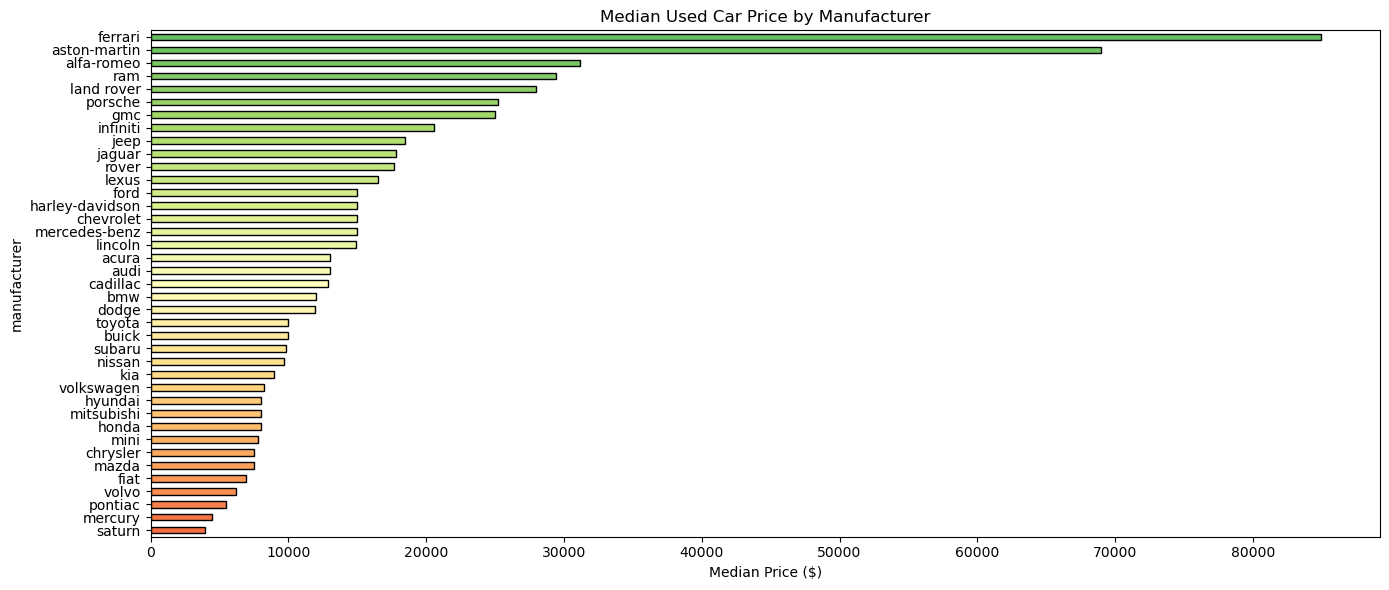

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
mfr_medians = df.groupby('manufacturer')['price'].median().sort_values(ascending=True)
mfr_medians.plot(kind='barh', color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(mfr_medians))), edgecolor='black', ax=ax)
ax.set_title('Median Used Car Price by Manufacturer'); ax.set_xlabel('Median Price ($)')
plt.tight_layout(); plt.show()

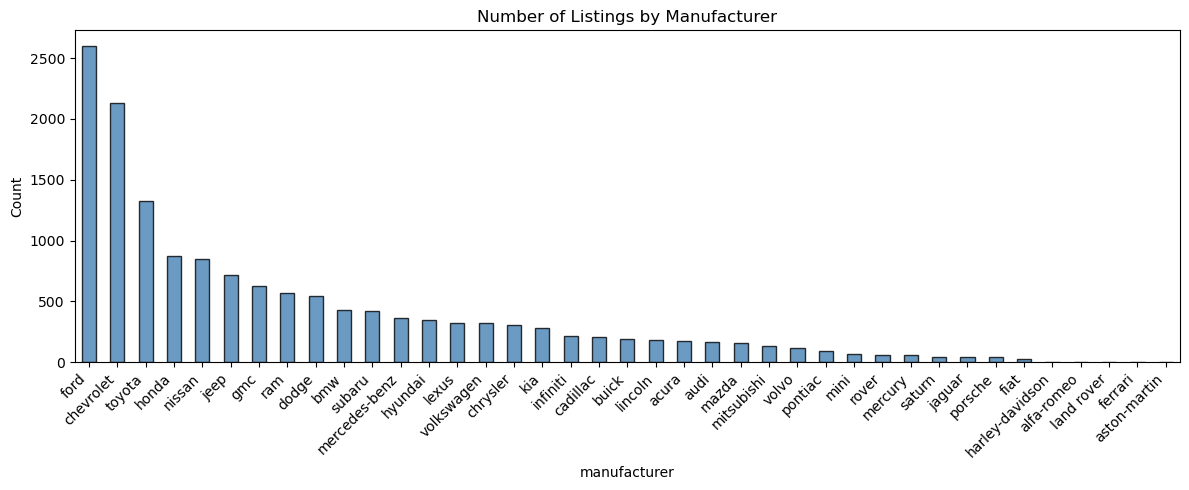

In [7]:
# Figure 3: Number of Listings by Manufacturer
fig, ax = plt.subplots(figsize=(12, 5))
df['manufacturer'].value_counts().sort_values(ascending=False).plot(
    kind='bar', color='steelblue', edgecolor='black', alpha=0.8, ax=ax)
ax.set_title('Number of Listings by Manufacturer')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

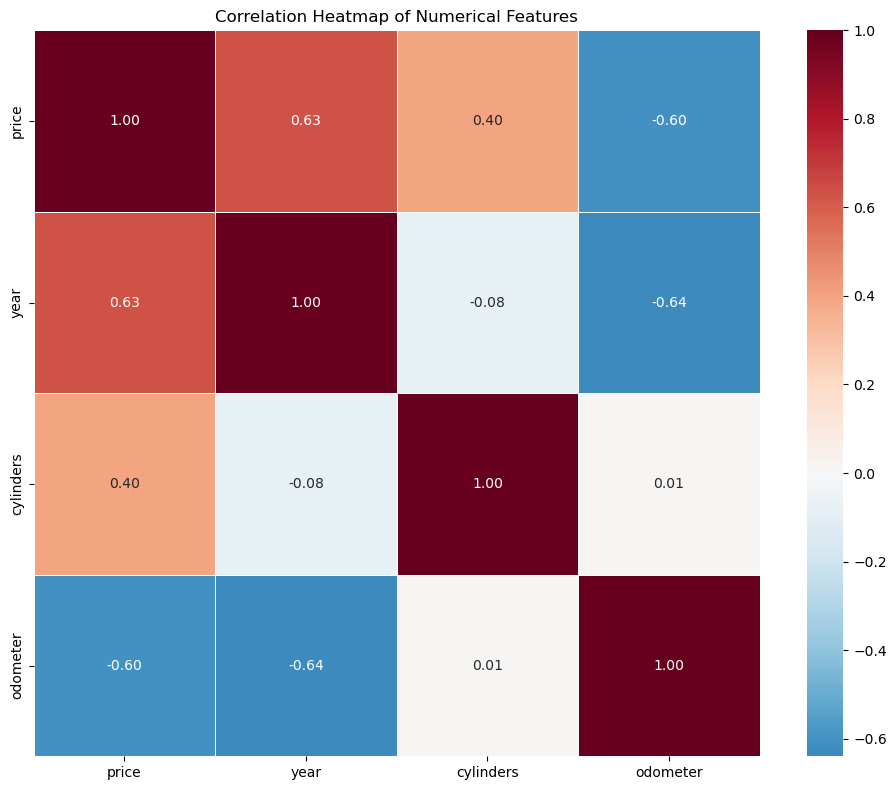

In [8]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features')
plt.tight_layout(); plt.show()

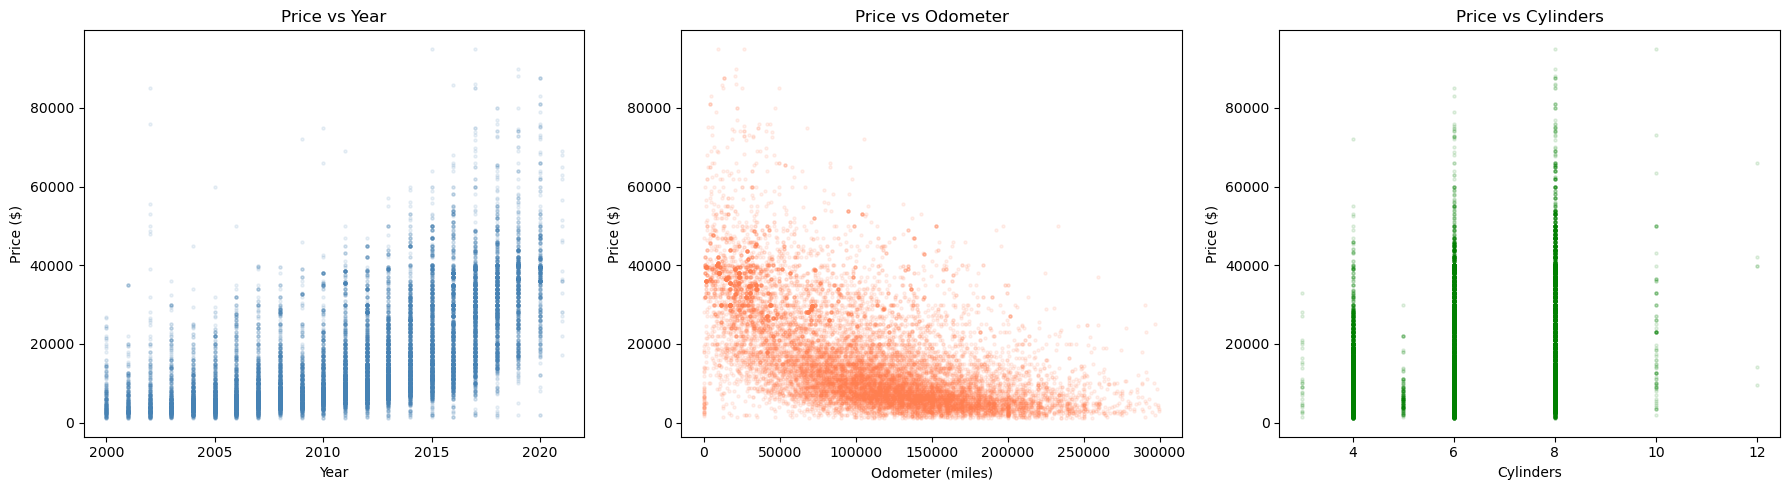

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(df['year'], df['price'], alpha=0.1, s=5, color='steelblue')
axes[0].set_title('Price vs Year'); axes[0].set_xlabel('Year'); axes[0].set_ylabel('Price ($)')
axes[1].scatter(df['odometer'], df['price'], alpha=0.1, s=5, color='coral')
axes[1].set_title('Price vs Odometer'); axes[1].set_xlabel('Odometer (miles)'); axes[1].set_ylabel('Price ($)')
axes[2].scatter(df['cylinders'], df['price'], alpha=0.1, s=5, color='green')
axes[2].set_title('Price vs Cylinders'); axes[2].set_xlabel('Cylinders'); axes[2].set_ylabel('Price ($)')
plt.tight_layout(); plt.show()

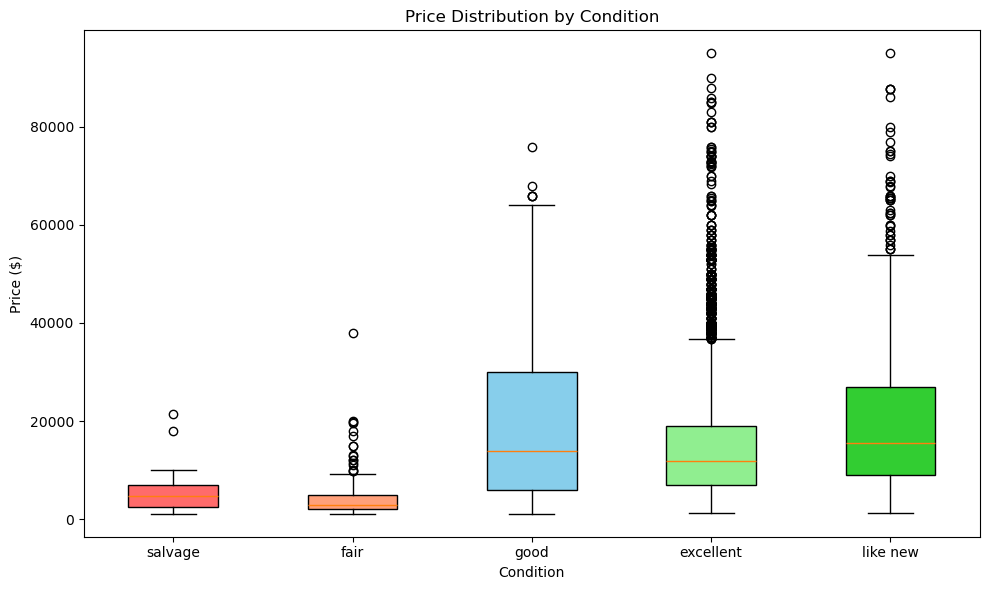

In [10]:
# Figure 6: Price Distribution by Condition
fig, ax = plt.subplots(figsize=(10, 6))
condition_order = ['salvage', 'fair', 'good', 'excellent', 'like new']
existing_conditions = [c for c in condition_order if c in df['condition'].unique()]
data_by_cond = [df[df['condition'] == c]['price'].values for c in existing_conditions]
bp = ax.boxplot(data_by_cond, labels=existing_conditions, patch_artist=True)
colors_box = ['#ff6b6b', '#ffa07a', '#87ceeb', '#90ee90', '#32cd32']
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors_box[i % len(colors_box)])
ax.set_title('Price Distribution by Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Price ($)')
plt.tight_layout()
plt.show()

==============================
3. Preprocessing
==============================

In [11]:
df_encoded = df.copy()
label_encoders = {}
categorical_cols = ['manufacturer', 'condition', 'fuel', 'transmission', 'drive', 'type', 'paint_color']
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded '{col}': {len(le.classes_)} unique values")

Encoded 'manufacturer': 39 unique values
Encoded 'condition': 6 unique values
Encoded 'fuel': 5 unique values
Encoded 'transmission': 3 unique values
Encoded 'drive': 3 unique values
Encoded 'type': 13 unique values
Encoded 'paint_color': 12 unique values


In [12]:
X = df_encoded.drop('price', axis=1).values
y = df_encoded['price'].values
feature_names = [c for c in df_encoded.columns if c != 'price']
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (15000, 10), y shape: (15000,)


In [13]:
def get_train_valid_test_data(X, y, train_ratio=0.8, valid_ratio=0.1, seed=42):
    np.random.seed(seed)
    n = len(X)
    indices = np.random.permutation(n)
    train_end = int(n * train_ratio)
    valid_end = int(n * (train_ratio + valid_ratio))
    return (X[indices[:train_end]], y[indices[:train_end]],
            X[indices[train_end:valid_end]], y[indices[train_end:valid_end]],
            X[indices[valid_end:]], y[indices[valid_end:]])

In [14]:
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_train_valid_test_data(X, y)
print(f"Training: {X_trn.shape}, Validation: {X_vld.shape}, Testing: {X_tst.shape}")

Training: (12000, 10), Validation: (1500, 10), Testing: (1500, 10)


In [15]:
scaler = StandardScaler()
X_trn_std = scaler.fit_transform(X_trn)
X_vld_std = scaler.transform(X_vld)
X_tst_std = scaler.transform(X_tst)

In [16]:
X_trn_b = np.hstack([np.ones((X_trn_std.shape[0], 1)), X_trn_std])
X_vld_b = np.hstack([np.ones((X_vld_std.shape[0], 1)), X_vld_std])
X_tst_b = np.hstack([np.ones((X_tst_std.shape[0], 1)), X_tst_std])

==============================
4. Metrics
==============================

In [17]:
def sse(y_true, y_pred):
    return float(np.sum((y_true - y_pred) ** 2))

In [18]:
def compute_mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

In [19]:
def compute_rmse(y_true, y_pred):
    return float(np.sqrt(compute_mse(y_true, y_pred)))

In [20]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - (ss_res / ss_tot))

==============================
5. OLS
==============================

In [21]:
class OrdinaryLeastSquares():
    def __init__(self):
        self.w = None

    def fit(self, X, y):
        self.w = np.linalg.pinv(X.T @ X) @ X.T @ y
        return self

    def predict(self, X):
        return X @ self.w

In [22]:
ols = OrdinaryLeastSquares()
ols.fit(X_trn_b, y_trn)
y_hat_ols_trn = ols.predict(X_trn_b)
y_hat_ols_vld = ols.predict(X_vld_b)
y_hat_ols_tst = ols.predict(X_tst_b)

In [23]:
print("OLS Results:")
print(f"  Train  RMSE: ${compute_rmse(y_trn, y_hat_ols_trn):,.2f}, R2: {r_squared(y_trn, y_hat_ols_trn):.4f}")
print(f"  Val    RMSE: ${compute_rmse(y_vld, y_hat_ols_vld):,.2f}, R2: {r_squared(y_vld, y_hat_ols_vld):.4f}")
print(f"  Test   RMSE: ${compute_rmse(y_tst, y_hat_ols_tst):,.2f}, R2: {r_squared(y_tst, y_hat_ols_tst):.4f}")

OLS Results:
  Train  RMSE: $6,979.61, R2: 0.7135
  Val    RMSE: $6,861.59, R2: 0.7082
  Test   RMSE: $6,638.64, R2: 0.7283


==============================
6. KNN Regression
==============================

In [24]:
class KNNRegressor():
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self

    def _predict_one(self, x):
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        k_indices = np.argsort(distances)[:self.k]
        return np.mean(self.y_train[k_indices])

    def predict(self, X):
        return np.array([self._predict_one(x) for x in X])

In [25]:
k_values = [1, 3, 5, 10, 25]
knn_results = {}
np.random.seed(42)
knn_idx = np.random.choice(len(X_trn_std), min(3000, len(X_trn_std)), replace=False)
vld_idx = np.random.choice(len(X_vld_std), min(500, len(X_vld_std)), replace=False)
tst_idx = np.random.choice(len(X_tst_std), min(500, len(X_tst_std)), replace=False)

In [26]:
for k in k_values:
    print(f"Training KNN with k={k}...")
    knn = KNNRegressor(k=k)
    knn.fit(X_trn_std[knn_idx], y_trn[knn_idx])
    y_hat_v = knn.predict(X_vld_std[vld_idx])
    y_hat_t = knn.predict(X_tst_std[tst_idx])
    knn_results[k] = {
        'vld_rmse': compute_rmse(y_vld[vld_idx], y_hat_v),
        'tst_rmse': compute_rmse(y_tst[tst_idx], y_hat_t),
        'vld_r2': r_squared(y_vld[vld_idx], y_hat_v),
        'tst_r2': r_squared(y_tst[tst_idx], y_hat_t),
        'y_hat_tst': y_hat_t
    }
    print(f"  Val RMSE: ${knn_results[k]['vld_rmse']:,.2f} | Test RMSE: ${knn_results[k]['tst_rmse']:,.2f}")

Training KNN with k=1...
  Val RMSE: $7,961.19 | Test RMSE: $6,878.46
Training KNN with k=3...
  Val RMSE: $6,778.26 | Test RMSE: $5,861.72
Training KNN with k=5...
  Val RMSE: $6,815.38 | Test RMSE: $5,863.15
Training KNN with k=10...
  Val RMSE: $6,705.43 | Test RMSE: $5,848.07
Training KNN with k=25...
  Val RMSE: $6,816.67 | Test RMSE: $6,117.52


In [27]:
best_k = min(knn_results, key=lambda k: knn_results[k]['vld_rmse'])
print(f"\nBest k: {best_k}")


Best k: 10


==============================
7. Results Visualizations
==============================

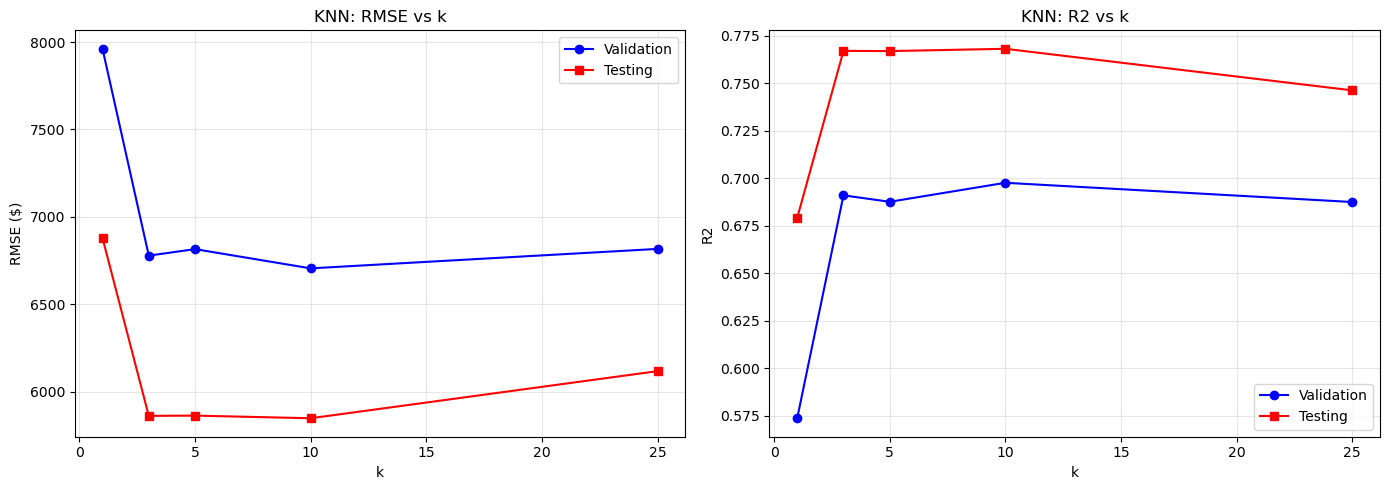

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_values, [knn_results[k]['vld_rmse'] for k in k_values], 'bo-', label='Validation')
axes[0].plot(k_values, [knn_results[k]['tst_rmse'] for k in k_values], 'rs-', label='Testing')
axes[0].set_title('KNN: RMSE vs k'); axes[0].set_xlabel('k'); axes[0].set_ylabel('RMSE ($)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(k_values, [knn_results[k]['vld_r2'] for k in k_values], 'bo-', label='Validation')
axes[1].plot(k_values, [knn_results[k]['tst_r2'] for k in k_values], 'rs-', label='Testing')
axes[1].set_title('KNN: R2 vs k'); axes[1].set_xlabel('k'); axes[1].set_ylabel('R2'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

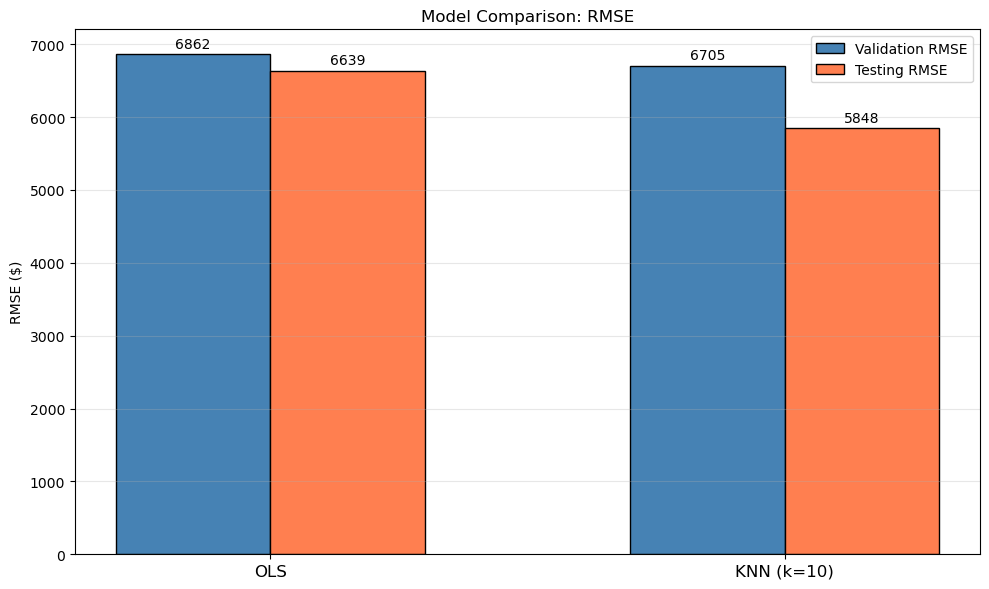

In [29]:
# Figure 8: Model Comparison - OLS vs KNN
fig, ax = plt.subplots(figsize=(10, 6))
models = ['OLS', f'KNN (k={best_k})']
vld_scores = [compute_rmse(y_vld, y_hat_ols_vld), knn_results[best_k]['vld_rmse']]
tst_scores = [compute_rmse(y_tst, y_hat_ols_tst), knn_results[best_k]['tst_rmse']]

x = np.arange(len(models))
width = 0.3
bars1 = ax.bar(x - width/2, vld_scores, width, label='Validation RMSE', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, tst_scores, width, label='Testing RMSE', color='coral', edgecolor='black')
ax.set_title('Model Comparison: RMSE')
ax.set_ylabel('RMSE ($)')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

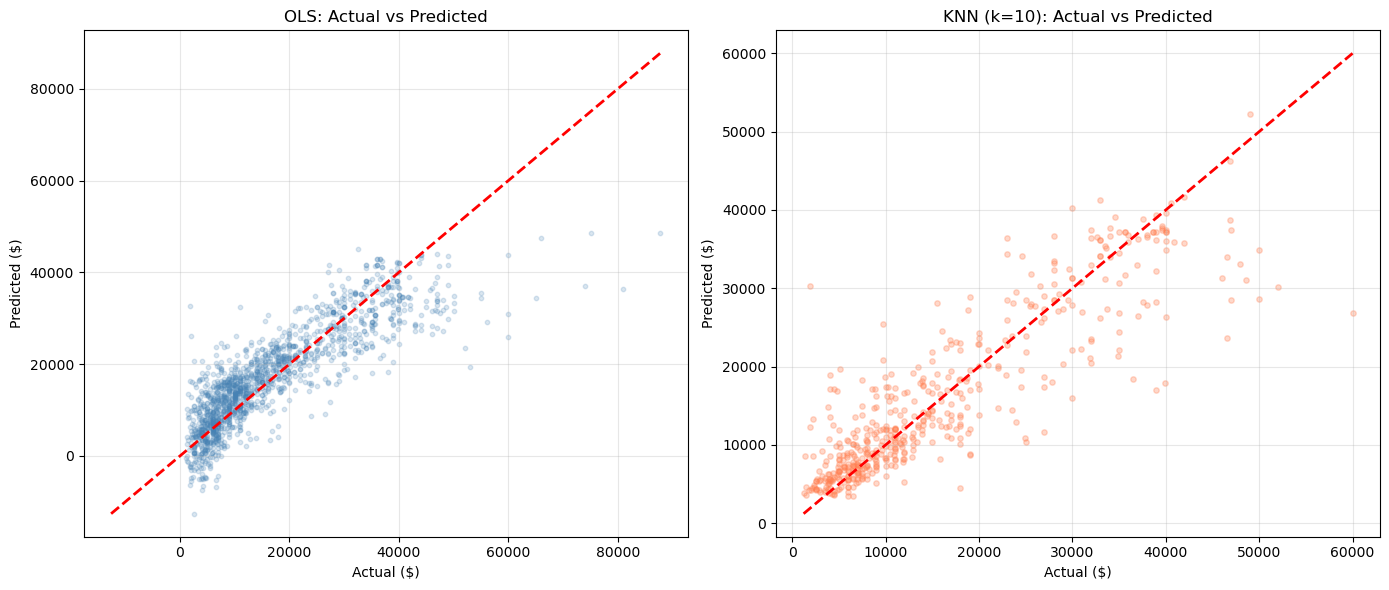

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(y_tst, y_hat_ols_tst, alpha=0.2, s=10, color='steelblue')
mn, mx = min(y_tst.min(), y_hat_ols_tst.min()), max(y_tst.max(), y_hat_ols_tst.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2); axes[0].set_title('OLS: Actual vs Predicted')
axes[0].set_xlabel('Actual ($)'); axes[0].set_ylabel('Predicted ($)'); axes[0].grid(True, alpha=0.3)
y_hat_best = knn_results[best_k]['y_hat_tst']
axes[1].scatter(y_tst[tst_idx], y_hat_best, alpha=0.3, s=15, color='coral')
mn2, mx2 = min(y_tst[tst_idx].min(), y_hat_best.min()), max(y_tst[tst_idx].max(), y_hat_best.max())
axes[1].plot([mn2, mx2], [mn2, mx2], 'r--', linewidth=2); axes[1].set_title(f'KNN (k={best_k}): Actual vs Predicted')
axes[1].set_xlabel('Actual ($)'); axes[1].set_ylabel('Predicted ($)'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

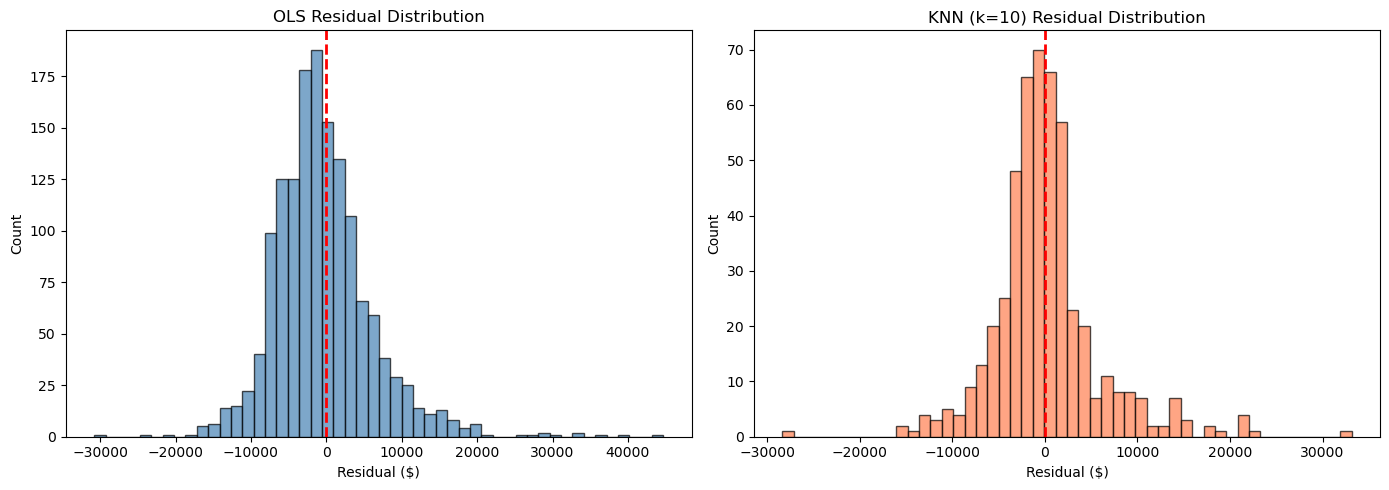

In [31]:
# Figure 10: Residual Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals_ols = y_tst - y_hat_ols_tst
axes[0].hist(residuals_ols, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('OLS Residual Distribution')
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Count')

residuals_knn = y_tst[tst_idx] - knn_results[best_k]['y_hat_tst']
axes[1].hist(residuals_knn, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f'KNN (k={best_k}) Residual Distribution')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [32]:
# ==============================
# 8. Summary
# ==============================
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"OLS Test RMSE:  ${compute_rmse(y_tst, y_hat_ols_tst):,.2f}, R2: {r_squared(y_tst, y_hat_ols_tst):.4f}")
print(f"KNN (k={best_k}) Test RMSE: ${knn_results[best_k]['tst_rmse']:,.2f}, R2: {knn_results[best_k]['tst_r2']:.4f}")

FINAL RESULTS
OLS Test RMSE:  $6,638.64, R2: 0.7283
KNN (k=10) Test RMSE: $5,848.07, R2: 0.7681
